In [92]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [93]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [94]:
def detrend_yearly(s):

    # Extract years and values
    years = s.year.values
    values = s.values

    # Fit a linear trend
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
    trend = slope * years + intercept

    # Detrend the data
    detrended_values = values - trend

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data

In [119]:
import numpy as np
import xarray as xr
from scipy import stats

def detrend_yearly_limited(s, start_year=1991, end_year=2020):
    # Extract years and values
    years = s.year.values
    values = s.values

    # Filter the data for the specified range (1990-2020)
    mask = (years >= start_year) & (years <= end_year)
    years_subset = years[mask]
    values_subset = values[mask]

    # Fit a linear trend to the subset of data
    slope, intercept, _, _, _ = stats.linregress(years_subset, values_subset)

    # Compute the trend based on the entire time span using the calculated slope and intercept
    trend = slope * years + intercept

    # Detrend the data
    detrended_values = values - trend

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data


###  Ocean Mask

In [96]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi

## SST mean

In [153]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))
#ocean_mask = ~sst.isel(time = 1).sst.isnull()
sst = sst.where(ocean_mask)

In [155]:
clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
#take sst_anom
sst['anom'] = sst.sst.groupby('time.month')-clim.sst

#all tropic mean anomaly
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_anom'] = sst.anom.weighted(weights).mean(['lat', 'lon'])

In [156]:
#compute ASO tropic wide anomaly
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

#detrend it
sst_aso_det_lim = detrend_yearly_limited(sst_aso.ocean_anom)

In [157]:
# compute nino34 for aso 
nino34 = sst.anom.sel(lat = slice(5, -5), lon = slice(190, 240))
nino34 = nino34.weighted(np.cos(np.deg2rad(nino34.lat))).mean(['lat', 'lon'])
nino34 = nino34.where(nino34.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
nino34 = nino34-nino34.mean()

## Sobel

In [10]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))
#ocean only
tp = tp.where(ocean_mask)

In [201]:
#threshold used in Sobel
P_0 = 6

In [202]:
sst_p = sst.sst.where(tp.tp>P_0)

In [203]:
weights = np.cos(np.deg2rad(sst_p.lat))
sst_p_mean = sst_p.weighted(weights).mean(['lat', 'lon'])

clim = sst_p_mean.groupby('time.month').mean()

sst_p_anom = sst_p_mean.groupby('time.month')-clim

In [204]:
sst_p_aso = sst_p_anom.where(sst_p.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
sst_p_aso_det_lim = detrend_yearly_limited(sst_p_aso, start_year = 1979)

## GPCP


In [198]:
fp = '/data/jmex/NOAA/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})





In [199]:
#load sst and coarsen

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(60, -60), time = slice('1979', '2023'))

sst = sst.where(ocean_mask)

In [200]:
#interp sst to match gpcp
sst = sst.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')

#second ocean_mask, on the GPCP grid
#make ocean mask
ocean_mask2 = ~sst.isel(time = 1).sst.isnull()

#take t for ocean mask only: 
tp = tp.where(ocean_mask2)

In [189]:
#weights
weights = np.cos(np.deg2rad(sst.lat))

#tp mean tropical (20-20)
tp_mean = tp.weighted(weights).mean(['lat', 'lon'])

#hadamard product of tp and sst
sst['sst_tp'] = sst.sst*tp.tp


#weigth by area
#sst['sst_tp'] = sst.sst_tp.weighted(weights).mean(['lat','lon'])

#normalise by tp mean
sst['sst_tp'] = sst.sst_tp/tp.tp

#anomaly
sst['sst_tp_anom'] = sst.sst_tp.groupby('time.month') - sst.sst_tp.groupby('time.month').mean()

sst['pws'] = sst.sst_tp_anom.weighted(weights).mean(['lat', 'lon'])

In [190]:
pws_aso = sst.pws.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
pws_aso_det_lim = detrend_yearly_limited(pws_aso)

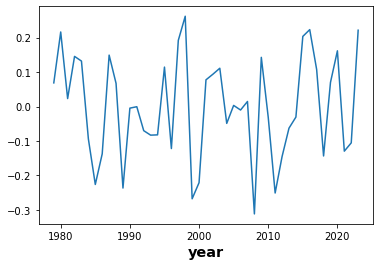

In [191]:
sst_p_aso_det_lim.plot()


### PWS

In [193]:
#take tp_anom instead
#tp['clim'] = tp.tp.groupby('time.month')
tp['anom'] = tp.tp.groupby('time.month')-tp.tp.groupby('time.month').mean()

In [198]:
#weights
weights = np.cos(np.deg2rad(sst.lat))

#tp mean tropical (20-20)
tp_mean = tp.weighted(weights).mean(['lat', 'lon'])

#hadamard product of tp and sst
sst['sst_tp'] = sst.sst*tp.tp
#weigth by area
sst['sst_tp'] = sst.sst_tp.weighted(weights).mean(['lat','lon'])

#normalise by tp mean
sst['sst_tp'] = sst.sst_tp/tp_mean.tp

In [203]:
pws_aso = sst.sst_tp.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()
pws_aso_det_lim = detrend_yearly_limited(pws_aso)

## Temperature


In [116]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', '2023'), lat = slice(25, -15)).sel(plev = 50000)
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])

In [117]:
#ASO season
t500_aso = t500.where(t500.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

clim = t500_aso.sel(year = slice('1990', '2020')).ocean_mean.mean('year')

#ASO anom
t500_aso['ocean_anom'] = t500_aso.ocean_mean - clim

In [118]:
t500_aso_det = detrend_yearly_limited(t500_aso.ocean_anom)

_________________________________________________

In [120]:
#detrended
t500_aso_det_lim = detrend_yearly_limited(t500_aso.ocean_anom)

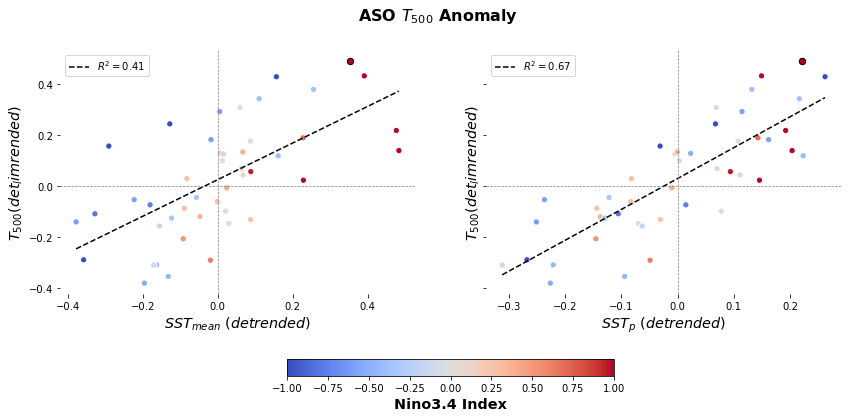

In [205]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



def plot_with_regression(ax, x, y, nino34, x_label):
    # Reshape for sklearn (requires 2D array for features)
    x_reshaped = x.reshape(-1, 1)

    # Regression
    model = LinearRegression()
    model.fit(x_reshaped, y)
    y_pred = model.predict(x_reshaped)
    r2 = r2_score(y, y_pred)

    # Scatter plot
    scatter = ax.scatter(x, y, c=nino34, cmap='coolwarm', vmin=-1, vmax=1, edgecolor='w', s=40)
    
    #highlight 2023
    scatter = ax.scatter(x[-1:], y[-1:], c=nino34[-1:], cmap='coolwarm', vmin=-1, vmax=1, edgecolor='k', s=40)
    
    
    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='black', linestyle='--', label=f'$R^2 = {r2:.2f}$')
    
    # Dashed lines at zero
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

    # Only display horizontal grid lines and remove the plot frame
    ax.yaxis.grid(False)  # Horizontal grid lines
    ax.xaxis.grid(False)  # No vertical grid lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(r'$T_{500} (det_limrended)$')
    
    ax.legend()
    
    #compute residuals
    residuals = y-y_pred

    return scatter, residuals

# Custom colormap for nino34 categories
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['darkblue', 'blue', 'white', 'red', 'darkred']
bounds = [-1.5, -1, -0.5, 0.5, 1, 1.5]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot 1
scatter1,_  = plot_with_regression(axes[0], sst_aso_det_lim.sel(year = slice('1960', '2023')).values, t500_aso_det_lim.sel(year = slice('1960', '2023')).values, nino34.sel(year = slice('1960', '2023')).values, x_label = r'$SST_{mean} \ (detrended)$')

# Plot 2
scatter2, residuals = plot_with_regression(axes[1], sst_p_aso_det_lim.sel(year = slice('1960', '2023')).values, t500_aso_det_lim.sel(year = slice('1960', '2023')).values, nino34.sel(year = slice('1960', '2023')).values, x_label = r'$SST_p \ (detrended)$')

# Set ticks to match the meaningful intervals only
cbar = fig.colorbar(scatter1, ax=axes, orientation='horizontal', fraction=0.05, pad=0.2)#, ticks=[-1.5, 1, 0, 1, 1.5])
cbar.set_label('Nino3.4 Index')
#cbar.ax.set_xticklabels(['Strong La Niña', 'La Niña', 'Neutral', 'El Niño', 'Strong El Niño'])

fig.suptitle(r"ASO $T_{500}$ Anomaly", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()


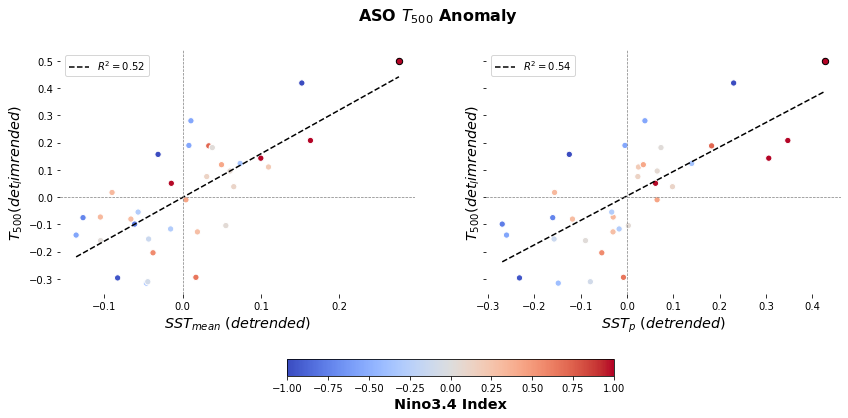

In [72]:

# Custom colormap for nino34 categories
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['darkblue', 'blue', 'white', 'red', 'darkred']
bounds = [-1.5, -1, -0.5, 0.5, 1, 1.5]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot 1
scatter1, _ = plot_with_regression(axes[0], sst_aso_det_lim.sel(year = slice('1990', '2023')).values, t500_aso_det_lim.sel(year = slice('1990', '2023')).values, nino34.sel(year = slice('1990', '2023')).values, x_label = r'$SST_{mean} \ (detrended)$')

# Plot 2
scatter2, residuals = plot_with_regression(axes[1], pws_aso_det_lim.sel(year = slice('1990', '2023')).values, t500_aso_det_lim.sel(year = slice('1990', '2023')).values, nino34.sel(year = slice('1990', '2023')).values, x_label = r'$SST_p \ (detrended)$')

# Set ticks to match the meaningful intervals only
cbar = fig.colorbar(scatter1, ax=axes, orientation='horizontal', fraction=0.05, pad=0.2)#, ticks=[-1.5, 1, 0, 1, 1.5])
cbar.set_label('Nino3.4 Index')
#cbar.ax.set_xticklabels(['Strong La Niña', 'La Niña', 'Neutral', 'El Niño', 'Strong El Niño'])

fig.suptitle(r"ASO $T_{500}$ Anomaly", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()

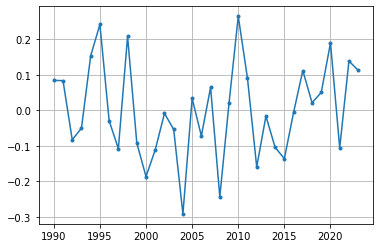

In [87]:
plt.plot(np.arange(1990, 2024, 1), residuals, marker = '.')
plt.grid()

## Residuals


data = pd.read_csv('/data/jmex/NOAA/tpi.timeseries.ersstv5.data',
            delim_whitespace=True, skiprows=1, header=None, nrows = 171)


tpi_aso = np.mean(data.iloc[106:170:,8:11:], axis = 1)
tpi_aso = tpi_aso/tpi_aso.std()

In [68]:
residuals = (residuals/residuals.std()).flatten()

fig, ax = plt.subplots(1,1, figsize = (12,6))

years = sst_p_aso_det_lim.year
ax.plot(years, residuals, label = 'residuals')

cbar = ax.scatter(years, residuals, c = nino34.values, cmap = 'coolwarm', vmin = -2, vmax = 2)

plt.plot(years, tpi_aso, label = 'tpi')


ax.axhline(0, linestyle = '--', c = 'grey')
ax.set_title('Residuals of T500(SST_p)')
ax.set_ylabel('Residuals [K]')
ax.set_xlabel('Year (ASO season)')
plt.colorbar(cbar, label = 'Nino34 ASO')
plt.legend()

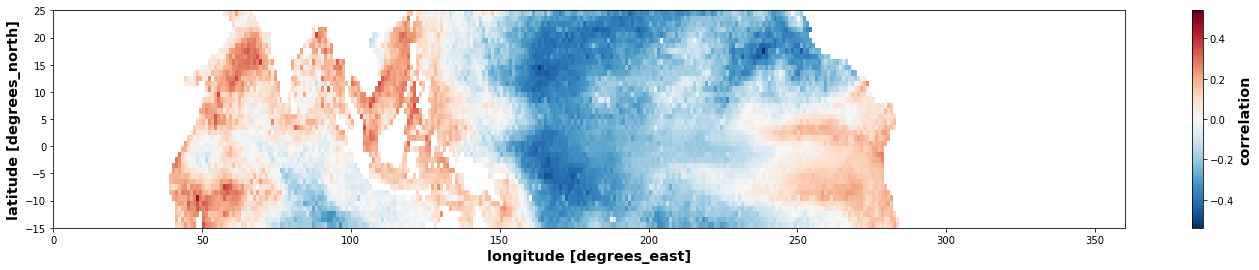

In [206]:
import numpy as np
import xarray as xr

# Assuming `sst_aso` is an xarray.Dataset and `residuals` is a numpy array
# Step 1: Extract the anomalies from the dataset
anom = sst_aso.sel(year = slice('1979', '2023'))['anom']  # shape: (year, lat, lon)

# Ensure residuals is reshaped to align with the time dimension of the anomalies
residuals = residuals.reshape(-1, 1, 1)  # shape: (year, 1, 1)

# Step 2: Normalize anomalies and residuals (remove mean, divide by std)
anom_mean = anom.mean(dim='year')
anom_std = anom.std(dim='year')
anom_norm = (anom - anom_mean) / anom_std  # shape: (year, lat, lon)

residuals_mean = residuals.mean(axis=0)  # Single scalar mean
residuals_std = residuals.std(axis=0)  # Single scalar std
residuals_norm = (residuals - residuals_mean) / residuals_std  # shape: (year, 1, 1)

# Step 3: Compute correlation
correlation = (anom_norm * residuals_norm).mean(dim='year')  # shape: (lat, lon)

# Step 4: Save or plot the correlation map
correlation_map = xr.DataArray(correlation, coords=[anom.lat, anom.lon], dims=["lat", "lon"])
correlation_map.name = "correlation"

# Optionally, save or plot the data
correlation_map.plot(size = 4, aspect = 6)  # Example of a quick plot


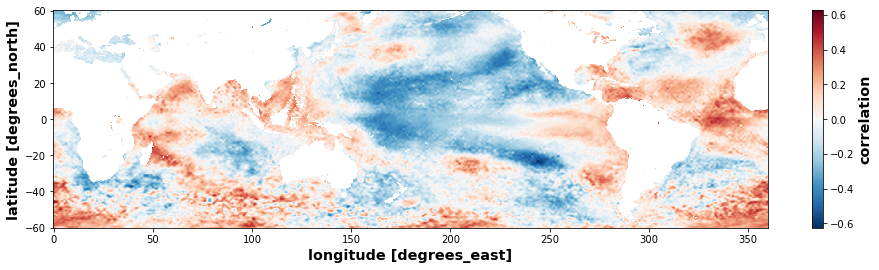

In [212]:
import numpy as np
import xarray as xr

# Assuming `sst_aso` is an xarray.Dataset and `residuals` is a numpy array
# Step 1: Extract the anomalies from the dataset
anom = sst_aso_anom  # shape: (year, lat, lon)

# Ensure residuals is reshaped to align with the time dimension of the anomalies
residuals = residuals.reshape(-1, 1, 1)  # shape: (year, 1, 1)

# Step 2: Normalize anomalies and residuals (remove mean, divide by std)
anom_mean = anom.mean(dim='year')
anom_std = anom.std(dim='year')
anom_norm = (anom - anom_mean) / anom_std  # shape: (year, lat, lon)

residuals_mean = residuals.mean(axis=0)  # Single scalar mean
residuals_std = residuals.std(axis=0)  # Single scalar std
residuals_norm = (residuals - residuals_mean) / residuals_std  # shape: (year, 1, 1)

# Step 3: Compute correlation
correlation = (anom_norm * residuals_norm).mean(dim='year')  # shape: (lat, lon)

# Step 4: Save or plot the correlation map
correlation_map = xr.DataArray(correlation, coords=[anom.lat, anom.lon], dims=["lat", "lon"])
correlation_map.name = "correlation"

# Optionally, save or plot the data
correlation_map.plot(size = 4, aspect = 4)  # Example of a quick plot


In [22]:
sst_fma = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [22]:
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [208]:
#load sst and coarsen

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(60, -60), time = slice('1979', '2023'))


In [209]:
clim = sst.sst.sel(time  = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - clim

In [211]:
sst_aso_anom = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean().anom